<a href="https://colab.research.google.com/github/SpolancoC/Mineria_de_datos_Duoc/blob/main/Parcial_1_StarCraft_II_Reyes_Polanco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial 1 - Minería de Datos

## Preparación de Datos - Starcraft II

**Asignatura:** BIY7121  
**Alumnos:** Nicolás Reyes, Sebastian Polanco
**Fecha:** 08-04-2026

---

## Introducción

El presente informe aplica las fases iniciales de la metodología CRISP-DM, específicamente Business Understanding y Data Understanding, utilizando un dataset del videojuego Starcraft II.

El objetivo es analizar patrones de comportamiento en los jugadores, identificar variables relevantes y obtener insights que apoyen la toma de decisiones.

## Metodología CRISP-DM

CRISP-DM (Cross Industry Standard Process for Data Mining) es una metodología ampliamente utilizada en proyectos de minería de datos.

### Fases:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

Estas fases nos permite estructurar el analisis de los datos, asegurando que los resultados esten alineados con los objetivos del negocio y facilitando la toma de decisiones.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv('/content/starcraft_duoc_variant_4.csv', sep=';')

# Mostrar primeras filas
df.head()

,GameID,LeagueIndex,Age,HoursPerWeek,TotalHours,APM,SelectByHotkeys,AssignToHotkeys,MinimapAttacks,MinimapRightClicks,NumberOfPACs,GapBetweenPACs,ActionLatency,ActionsInPAC,TotalMapExplored,WorkersMade,UniqueUnitsMade,ComplexUnitsMade,ComplexAbilityUsed,MaxTimeStamp
0,-4.875846,4.973033,26.959702,11.007906,3254.933673,1.148.028,0.001190084,0.000314362,2.25e-05,0.000426634,0.004860,307.786,609.302,46.330793,0.000218,0.0007859,5.99e-05,0.000396695,0.00082333,127536.646762
1,-18.701477,5.075755,23.288723,9.171584,5226.522033,1.293.624,0.001593488,6.88e-05,2.87e-05,0.001089075,0.004285,389.697,482.036,48.634785,0.000379,0.00054454,4.59e-05,9.74e-05,0.00022355,57484.874057
2,-26.674070,4.025909,30.333678,9.186766,-274.878548,2.360.316,0.015663583,0.001014942,0.000366216,0.001632277,0.002899,187.787,299.871,3.138191,0.000233,0.0015067,8.37e-05,0,0,95604.948518
3,183.146504,3.003114,18.983180,20.068677,231.529776,1.905.402,0.012626514,0.001144848,0.000506056,0.000738344,0.003835,23.56,507.232,48.792258,0.000211,0.00073005,4.98e-05,0.000132736,4.15e-05,94018.581233
4,134.486489,3.063233,31.933262,9.161646,180.354567,962.466,0.00121307,0.00023033,0.000138198,0.000537436,0.002430,274.341,617.476,8.853681,0.000288,0.00078312,9.21e-05,0,0.00015355,52428.441022


## Fase 1: Business Understanding

### Contexto
Starcraft II es un videojuego de estrategia en tiempo real donde los jugadores deben gestionar recursos, tomar decisiones rápidas y ejecutar múltiples acciones simultáneamente.

En el contexto competitivo (eSports), el rendimiento de los jugadores depende de variables como:

- Velocidad de acción (APM)
- Toma de decisiones
- Control de unidades
- Conciencia del mapa

El análisis de estos datos permite identificar patrones de rendimiento, diferenciar niveles de habilidad y apoyar la toma de decisiones estratégicas.

### Objetivo general
Analizar el comportamiento de los jugadores para identificar factores que influyen en su desempeño competitivo.

### Objetivos específicos
- Analizar eficiencia en la ejecución de acciones
- Evaluar patrones de comportamiento
- Identificar variables clave del rendimiento

## KPIs (Indicadores Clave de Desempeño)

A continuación, se definen los principales indicadores clave de desempeño (KPIs) para evaluar el rendimiento de los jugadores en StarCraft II, alineados con los objetivos del negocio y el análisis de datos.

#1. KPI de Nivel Competitivo del Jugador (LeagueIndex)

**Qué mide:**  
El nivel competitivo del jugador dentro del sistema de ligas del juego.

**Justificación:**  
El LeagueIndex representa directamente la habilidad del jugador, clasificándolo desde ligas bajas (Bronze) hasta niveles profesionales. Este KPI permite segmentar a los jugadores y analizar cómo las diferentes variables del dataset influyen en su rendimiento.  

Además, sirve como referencia principal para validar si métricas como APM, latencia y producción de unidades realmente reflejan el nivel de habilidad esperado.

### 2. KPI de Velocidad y Reacción (APM / Action Latency)

**Qué mide:**  
La eficiencia del jugador en términos de rapidez y capacidad de respuesta.

**Justificación:**  
No basta con tener un APM alto si la latencia de reacción es elevada. Este KPI permite identificar jugadores que no solo realizan muchas acciones, sino que también responden rápidamente a los eventos del juego.  

Se espera que jugadores de ligas altas presenten valores altos en este indicador.

### 3. KPI de Capacidad Macroeconómica (Workers Made / Max TimeStamp)

**Qué mide:**  
La tasa de producción de trabajadores a lo largo del tiempo de juego.

**Justificación:**  
Una buena economía es clave en StarCraft II. Los jugadores más avanzados mantienen una producción constante de trabajadores, lo que les permite sostener su crecimiento económico y estratégico durante la partida.

### 4. KPI de Control de Unidades Especializadas (Complex Units / Total Units)

**Qué mide:**  
La proporción de unidades avanzadas utilizadas por el jugador.

**Justificación:**  
Las unidades complejas requieren mayor habilidad y control. Este KPI permite diferenciar a jugadores que dominan estrategias avanzadas frente a aquellos que solo utilizan unidades básicas.

### 5. KPI de Conciencia de Mapa (Minimap Attacks + Minimap Right Clicks)

**Qué mide:**  
El nivel de interacción del jugador con el minimapa.

**Justificación:**  
La conciencia del mapa es una habilidad crítica en el juego competitivo. Jugadores de alto nivel revisan constantemente el minimapa para anticipar movimientos del oponente.  

Valores altos en este KPI indican mejor toma de decisiones y mayor control estratégico.

## Fase 2: Data Understanding

### Descripción
El dataset contiene información sobre:
- Acciones del jugador
- Tiempos de ejecución
- Variables de rendimiento
- Nivel competitivo



##Tipo de datos

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3395 entries, 0 to 3394
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GameID              3395 non-null   float64
 1   LeagueIndex         3395 non-null   float64
 2   Age                 3340 non-null   float64
 3   HoursPerWeek        3339 non-null   float64
 4   TotalHours          3338 non-null   float64
 5   APM                 3395 non-null   object 
 6   SelectByHotkeys     3395 non-null   object 
 7   AssignToHotkeys     3395 non-null   object 
 8   MinimapAttacks      3395 non-null   object 
 9   MinimapRightClicks  3395 non-null   object 
 10  NumberOfPACs        3395 non-null   float64
 11  GapBetweenPACs      3395 non-null   object 
 12  ActionLatency       3395 non-null   object 
 13  ActionsInPAC        3395 non-null   float64
 14  TotalMapExplored    3395 non-null   float64
 15  WorkersMade         3395 non-null   object 
 16  Unique

### Naturaleza de los datos
- Numéricos: métricas de rendimiento
- Categóricos: nivel del jugador
- Continuos: tiempos y frecuencias

##Valores nulos

In [32]:
df.isnull().sum()

,0
GameID,0
LeagueIndex,0
Age,55
HoursPerWeek,56
TotalHours,57
APM,0
SelectByHotkeys,0
AssignToHotkeys,0
MinimapAttacks,0
MinimapRightClicks,0


**Análisis de Valores Nulos**

Al analizar los valores nulos del dataset, se observa que la mayoría de las variables no presentan datos faltantes. Sin embargo, existen algunas excepciones:

- Age: 55 valores nulos
- HoursPerWeek: 56 valores nulos
- TotalHours: 57 valores nulos

Estas variables corresponden a información demográfica y de dedicación del jugador, las cuales son relevantes para el análisis del comportamiento.

La baja cantidad de valores nulos en comparación con el total de registros sugiere que no representan un problema crítico, pero deben ser tratados para evitar sesgos en el análisis.

**Estrategia de Limpieza de Datos**

Para el tratamiento de los valores nulos se propone:

- Aplicar imputación mediante la mediana en las variables numéricas (Age, HoursPerWeek, TotalHours), ya que estas pueden presentar distribución no normal y la mediana es menos sensible a valores extremos.
- Evitar la eliminación de registros, dado que la cantidad de valores nulos es baja y eliminar filas podría significar pérdida innecesaria de información.

Esta estrategia permite mantener la integridad del dataset y mejorar la calidad del análisis posterior.

##Estadística descriptiva

In [34]:
display(df.describe())

# Dimensiones
display(df.shape)

,GameID,LeagueIndex,Age,HoursPerWeek,TotalHours,NumberOfPACs,ActionsInPAC,TotalMapExplored,MaxTimeStamp
count,3395.000000,3395.000000,3340.000000,3339.000000,3338.000000,3395.000000,3395.000000,3395.000000,3395.000000
mean,4805.609044,4.182909,21.655706,15.918212,983.810910,0.003463,47.201097,0.000282,83634.135437
std,2723.252435,1.519457,4.212658,11.971237,17336.935158,0.000994,20.632479,0.000087,33532.029939
min,-111.532726,0.736692,15.410982,-0.210229,-2874.480586,0.000614,1.065888,0.000097,23740.877051
25%,2466.570841,3.020919,18.550992,7.968531,-3.109542,0.002755,38.973207,0.000224,60041.569216
50%,4880.333069,4.066688,21.008164,12.261038,635.696883,0.003394,48.752507,0.000270,81060.989281
75%,7104.933905,5.065450,23.990402,20.624177,1299.551335,0.004037,58.612477,0.000326,102324.431745
max,10376.255681,8.115763,43.713283,167.127258,999943.895967,0.007950,185.623618,0.000833,390352.835574


(3395, 20)

Insights:
- Alta variabilidad en APM, indica distintos niveles de habilidad
- Diferencias en WorkersMade, indica estilos de juego distintos
- Edad diversa, indica jugadores heterogéneos

## Análisis de outliers

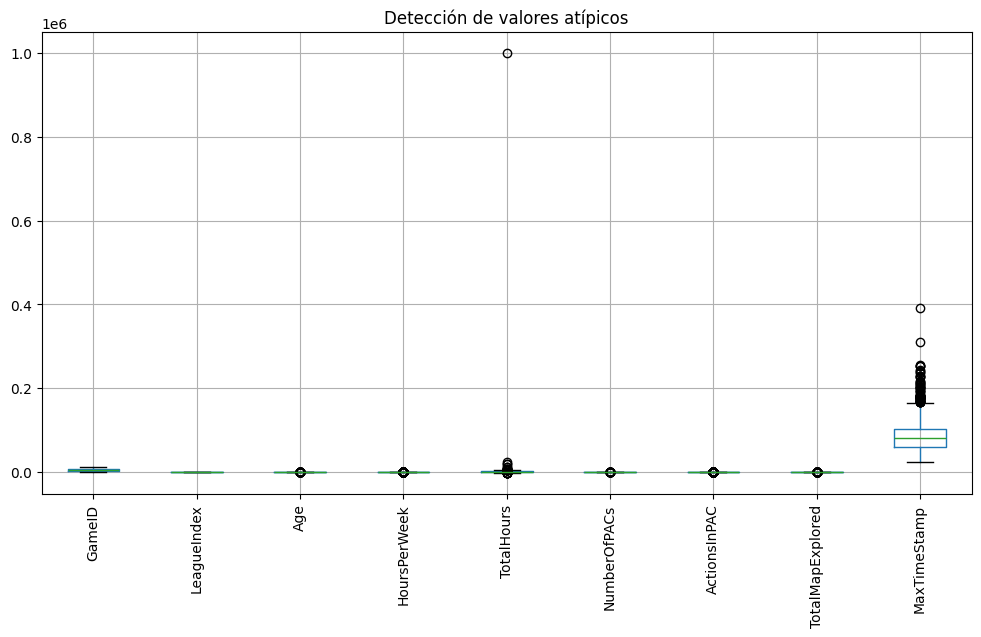

In [35]:
plt.figure(figsize=(12,6))
df.boxplot(rot=90)
plt.title("Detección de valores atípicos")
plt.show()

Se observan valores atípicos que pueden representar:
- Jugadores expertos
- Errores en los datos

### Propuesta:
- Eliminación de valores extremos
- Transformaciones como normalización o escalado
- Uso de métricas robustas como la mediana

##Correlación

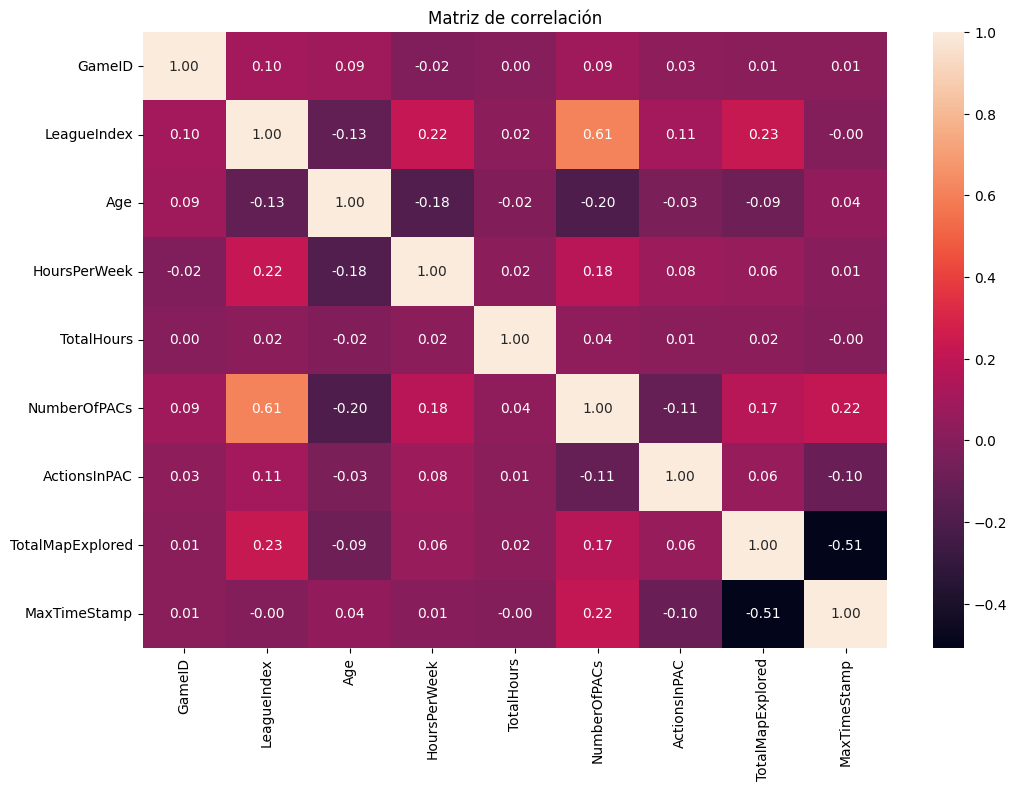

In [36]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

## Interpretación de correlación

La matriz de correlación fue calculada considerando únicamente variables numéricas, ya que este método requiere datos cuantitativos para medir relaciones lineales entre variables.

A partir del análisis se identifican las siguientes relaciones relevantes:

- Correlaciones positivas: relación directa
- Correlaciones negativas: relación inversa

- Existe una correlación positiva moderada entre LeagueIndex y NumberOfPACs (0.61), lo que indica que jugadores de ligas más altas tienden a realizar más acciones por ciclo, reflejando mayor actividad y control del juego.

- Se observa una correlación negativa entre Age y variables de desempeño como NumberOfPACs (-0.19), lo que sugiere que jugadores más jóvenes podrían tener mayor velocidad de ejecución.

- La correlación negativa entre TotalMapExplored y MaxTimeStamp (-0.51) indica que partidas más largas no necesariamente implican mayor exploración del mapa, lo que puede estar asociado a estilos de juego más defensivos o pasivos.

- Variables como HoursPerWeek y LeagueIndex presentan una correlación positiva (0.19), lo que sugiere que dedicar más tiempo al juego se asocia con un mejor nivel competitivo.

En general, se observa que el rendimiento del jugador está influenciado por múltiples variables interrelacionadas, siendo especialmente relevantes aquellas asociadas a la velocidad de acciones y toma de decisiones.


## Insights relevantes

- La eficiencia de acciones es más relevante que la cantidad total
- Jugadores con mayor consistencia presentan mejor desempeño
- Existen variables con alta correlación útiles para modelado
- LeagueIndex refleja correctamente el nivel de habilidad

Estos hallazgos permiten comprender mejor el comportamiento competitivo.

## Próximas fases CRISP-DM

### Data Preparation
- Limpieza de datos
- Normalización
- Selección de variables

### Modeling
- Clasificación de jugadores
- Clustering de estilos de juego

### Evaluation
- Validación de modelos

### Deployment
- Implementación de soluciones analíticas

## Conclusión

El análisis permitió comprender las características del dataset, identificar patrones relevantes y detectar problemas de calidad de datos.

La aplicación de CRISP-DM facilita el desarrollo estructurado del análisis y prepara el camino para futuras fases de modelamiento.